**Суть проблемы:** При переобучении классический МНК ($e^T e \rightarrow \min$) выдает огромные по модулю коэффициенты.
**Решение:** Добавить к функции потерь штраф $g(\beta)$ за величину коэффициентов:
$$e^T e + \lambda g(\beta) \rightarrow \min$$




---

### 3. Подбор параметра $\lambda$ (Кросс-валидация LOOCV)
1. Выбираем конкретное $\lambda$.
2.  По очереди исключаем из выборки по 1 точке.
3. Обучаем модель на оставшихся и делаем прогноз для выкинутой.
4. Вычисляем ошибку прогноза: $CVSS_i = (y_i - \tilde{y}_i)^2$.
5. Складываем все ошибки: $CVSS(\lambda) = \sum CVSS_i$.
6. **Итог:** Ищем такое $\lambda$, при котором график $CVSS$ достигает минимума. Затем по этому $\lambda$ строим финальную модель на *всех* данных.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import LeaveOneOut

In [10]:
# Матрица (столбцы соответствуют факторам ξ и η)
Psi = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])

Y = np.array([1, 5, 2])

F = Psi.T @ Psi
F_inv = np.linalg.inv(F)

# вектор оценок параметров β̃ = (a, b)^T
beta_tilde = F_inv @ Psi.T @ Y
a, b = beta_tilde

print("\nВектор оценок параметров β̃:")
print(f"a = {a:.4f}")
print(f"b = {b:.4f}")

# расчет RSS для сравнения с другими методами
Y_pred = Psi @ beta_tilde
e = Y - Y_pred
RSS = np.sum(e**2)

print(f"\nRSS = {RSS:.4f}")

print(f"\nУравнение линейной регрессии:")
print(f"ω = {a:.4f}·ξ + {b:.4f}·η")


Вектор оценок параметров β̃:
a = -0.3333
b = 3.6667

RSS = 5.3333

Уравнение линейной регрессии:
ω = -0.3333·ξ + 3.6667·η


### Ridge регрессия (Гребневая)
* **Ограничение (штраф):** Сумма квадратов коэффициентов ($\beta^T \beta \le t$).
* **Функция Лагранжа:** $L = e^T e + \lambda \beta^T \beta \rightarrow \min$
* **Геометрия:** Допустимая область — **круг** (сфера).
* **Матричное решение:** Существует. К диагонали матрицы Фишера прибавляется $\lambda$, что спасает её от вырожденности ($\det = 0$):
  $$\tilde{\beta}_{ridge} = (F + \lambda E)^{-1} \Psi^T Y$$
* **Эффект:** Стягивает коэффициенты к нулю, но *никогда не зануляет их полностью*.


Оптимальный параметр λ: 1.5030
ridge-регрессия: ω = 0.3113·ξ + 1.9094·η


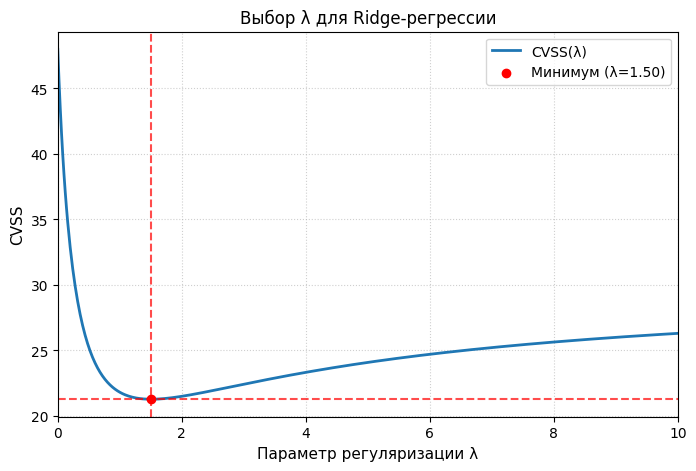

In [15]:
N, k = Psi.shape
E = np.eye(k)

# задаем сетку для λ от 0 до 10
lambdas = np.linspace(0, 10, 500)
cvss_values = []

for lam in lambdas:
    cvss = 0
    for i in range(N):
        # выкидываем i-е наблюдение
        Psi_train = np.delete(Psi, i, axis=0)
        Y_train = np.delete(Y, i)

        F = Psi_train.T @ Psi_train

        # оценки ridge
        beta_tilde = np.linalg.solve(F + lam * E, Psi_train.T @ Y_train)

        # считаем ошибку на выкинутом наблюдении: (y_i - Ψ_i * β_tilde)^2
        error = Y[i] - Psi[i] @ beta_tilde
        cvss += error**2

    cvss_values.append(cvss)

# поиск минимума
opt_idx = np.argmin(cvss_values)
lam_opt = lambdas[opt_idx]
min_cvss = cvss_values[opt_idx]

# итоговая модель по всей выборке с оптимальным λ
F_full = Psi.T @ Psi
a_opt, b_opt = np.linalg.solve(F_full + lam_opt * E, Psi.T @ Y)

print(f"Оптимальный параметр λ: {lam_opt:.4f}")
# print(f"min CVSS: {min_cvss:.4f}")
print(f"ridge-регрессия: ω = {a_opt:.4f}·ξ + {b_opt:.4f}·η")

plt.figure(figsize=(8, 5))
plt.plot(lambdas, cvss_values, color='#1f77b4', linewidth=2, label='CVSS(λ)')

plt.axvline(lam_opt, color='red', linestyle='--', alpha=0.7)
plt.axhline(min_cvss, color='red', linestyle='--', alpha=0.7)
plt.scatter(lam_opt, min_cvss, color='red', zorder=5, label=f'Минимум (λ={lam_opt:.2f})')

plt.title('Выбор λ для Ridge-регрессии', fontsize=12)
plt.xlabel('Параметр регуляризации λ', fontsize=11)
plt.ylabel('CVSS', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 10)
plt.show()

### 2. Lasso регрессия
* **Ограничение (штраф):** Сумма модулей коэффициентов ($\sum |\beta_i| \le t$).
* **Функция Лагранжа:** $L = e^T e + \lambda \sum |\beta_i| \rightarrow \min$
* **Геометрия:** Допустимая область — **ромб**. Касание происходит на осях.
* **Матричное решение:** Отсутствует (считается только численными методами).
* **Эффект:** Способна **строго занулять** наименее важные коэффициенты.

Оптимальный λ: 5.9697
lasso-регрессия: ω = 0.0000·ξ + 1.2614·η


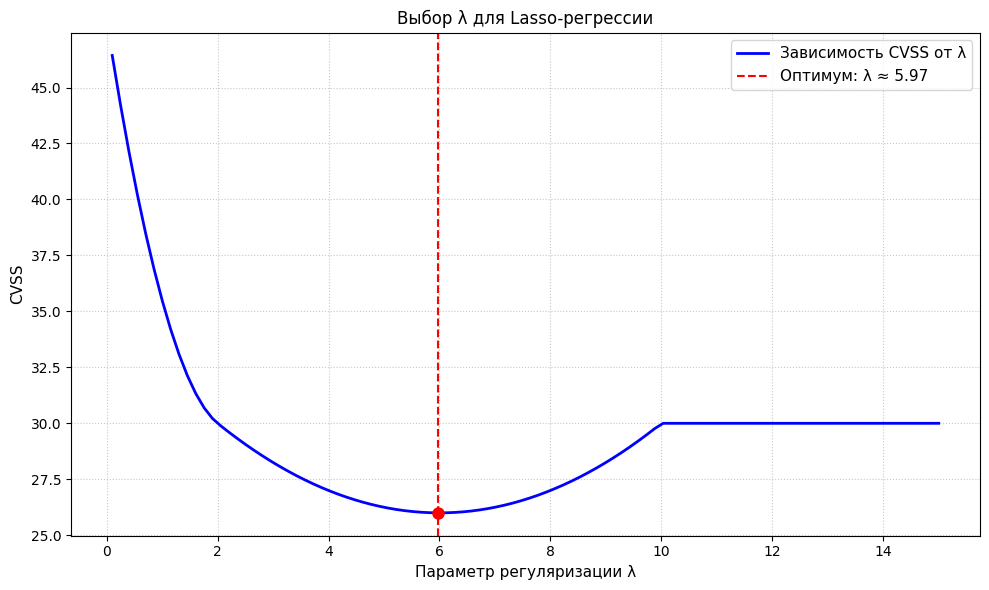

In [14]:
N = len(Y)

# сетка λ
lambdas = np.linspace(0.1, 15, 100)

# переводим классическую λ в alpha для scikit-learn (где n_samples = N - 1)
scaler = 2 * (N - 1)
alphas_sklearn = lambdas / scaler

lasso = LassoCV(alphas=alphas_sklearn, cv=LeaveOneOut(), fit_intercept=False)
lasso.fit(Psi, Y)

# LassoCV автоматически сортирует сетку по убыванию, сохраняем её и возвращаем масштаб
lambdas_plot = lasso.alphas_ * scaler
cvss_lasso = lasso.mse_path_.sum(axis=1) # это и есть CVSS

# возвращаем оптимальному значению классический масштаб
opt_lambda = lasso.alpha_ * scaler

print(f"Оптимальный λ: {opt_lambda:.4f}")
print(f"lasso-регрессия: ω = {lasso.coef_[0]:.4f}·ξ + {lasso.coef_[1]:.4f}·η")

plt.figure(figsize=(10, 6))

plt.plot(lambdas_plot, cvss_lasso, color='blue', lw=2, label='Зависимость CVSS от λ')
plt.axvline(opt_lambda, color='red', linestyle='--', label=f'Оптимум: λ ≈ {opt_lambda:.2f}')
plt.plot(opt_lambda, cvss_lasso.min(), 'ro', markersize=8)

plt.title('Выбор λ для Lasso-регрессии', fontsize=12)
plt.xlabel('Параметр регуляризации λ', fontsize=11)
plt.ylabel('CVSS', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()